# Comparison Againts Baseline

In [1]:
def default_params(): 
    return {
        'current_model': 'M1', 
        'quantization': 'none', #['none',"int4", "int8", "float32", "float16"]
        'propensity_threshold': 0.5,
        'psc_column': 'code_smell_psc_relative', #code_smell_actual_prob_median, #code_smell_max_prob_median, #code_smell_min_prob_median, #code_smell_actual_prob_mean, #code_smell_max_prob_mean, #code_smell_min_prob_mean, #code_smell_psc_entropy, #code_smell_psc_relative  
        'psc_distributions_conditioned_file' : '/workspaces/CodeSmells/data/extension/transformation/alignments/M1_q_none/curated/aligned_smells.json',
        'decoding_strategy': 'sampling', #['curated','greedy_search', 'beam_search', 'sampling', 'contrastive_search', 'top_k_sampling', 'top_p_sampling'],
        'alignments_path': '/workspaces/CodeSmells/data/extension/generation/alignments',
        'output_path': '/workspaces/CodeSmells/data/extension/baselines',
        'cache_dir': '/workspaces/CodeSmells/datax/hugging_face_cache',
    }
params = default_params()


### Imports

In [2]:
import pandas as pd
from codebleu import calc_codebleu
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import statistics as stats
from sklearn.metrics import precision_score, recall_score, f1_score, mutual_info_score
import os
import numpy as np
import pandas as pd
from codebleu import calc_codebleu
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from scipy.stats import entropy
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, to_rgb


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [4]:
### GENERATED
psc_distributions_unconditioned_df = pd.read_json(f"{params['alignments_path']}/{params['current_model']}_q_{params['quantization']}/{params['decoding_strategy']}/aligned_smells.json")

### GROUND TRUTH
psc_distributions_conditioned_df = pd.read_json(params['psc_distributions_conditioned_file'])

In [5]:
psc_distributions_conditioned_df.columns

Index(['id', 'commit_id', 'repo', 'path', 'file_name', 'fun_name',
       'commit_message', 'code', 'url', 'language', 'ast_errors',
       'n_ast_errors', 'ast_levels', 'n_whitespaces', 'n_words', 'vocab_size',
       'complexity', 'nloc', 'token_counts', 'n_ast_nodes', 'n_identifiers',
       's_msg_id', 's_line', 's_column', 's_end_line', 's_end_column',
       's_code', 'category', 'input_lenght', 'input_ids', 'max_prob',
       'min_prob', 'actual_prob', 'loss', 'code_smell_pos',
       'code_smell_actual_logits', 'code_smell_max_logits',
       'code_smell_min_logits', 'code_smell_actual_prob_median',
       'code_smell_max_prob_median', 'code_smell_min_prob_median',
       'code_smell_actual_prob_mean', 'code_smell_max_prob_mean',
       'code_smell_min_prob_mean', 'code_smell_psc_entropy',
       'code_smell_psc_relative'],
      dtype='object')

### Baselines Computation

In [6]:
def calculate_code_smell_proportion(psc_distributions_conditioned_df, psc_distributions_unconditioned_df, target_smell_id=None):
    conditioned_df = psc_distributions_conditioned_df.copy()
    unconditioned_df = psc_distributions_unconditioned_df.copy()
    # Filter unconditioned DataFrame by target smell ID if specified
    if target_smell_id is not None:
        unconditioned_df = unconditioned_df[unconditioned_df['s_msg_id'] == target_smell_id].copy()
        conditioned_df = conditioned_df[conditioned_df['s_msg_id'] == target_smell_id].copy()

    # Extract IDs for comparison
    matching_ids = sorted(unconditioned_df[unconditioned_df['id'].isin(conditioned_df['id'])]['id'].tolist())
    total_conditioned_ids = sorted(conditioned_df['id'].tolist())

    # Remove duplicates
    matching_ids = list(set(matching_ids))
    total_conditioned_ids = list(set(total_conditioned_ids))

    # Calculate the proportion of matching IDs
    proportion = len(matching_ids) / len(total_conditioned_ids) if total_conditioned_ids else 0

    return proportion

In [7]:
def calculate_code_smell_percentage(psc_distributions_conditioned_df, psc_distributions_unconditioned_df, target_smell_id=None):
    conditioned_df = psc_distributions_conditioned_df.copy()
    unconditioned_df = psc_distributions_unconditioned_df.copy()
    # Filter unconditioned DataFrame by target smell ID if specified
    if target_smell_id is not None:
        unconditioned_df = unconditioned_df[unconditioned_df['s_msg_id'] == target_smell_id].copy()
        conditioned_df = conditioned_df[conditioned_df['s_msg_id'] == target_smell_id].copy()

    return len(unconditioned_df) / len(conditioned_df) if len(conditioned_df) > 0 else 0

In [8]:

def _align_code_dfs(conditioned_df, unconditioned_df, target_smell_id=None, code_suffixes=('_predicted', '_reference')):
    """
    Helper to filter, sort, and align DataFrames by 'id' and 'code'.
    Returns a DataFrame with columns: id, code_predicted, code_reference.
    """
    if target_smell_id is not None:
        conditioned_df = conditioned_df[conditioned_df['s_msg_id'] == target_smell_id]
        unconditioned_df = unconditioned_df[unconditioned_df['s_msg_id'] == target_smell_id]
    # Sort and align by 'id'
    conditioned_df = conditioned_df.sort_values('id')
    unconditioned_df = unconditioned_df.sort_values('id')
    # Only keep matching ids
    aligned_df = unconditioned_df[unconditioned_df['id'].isin(conditioned_df['id'])].merge(
        conditioned_df[['id', 'code']], on='id', suffixes=code_suffixes
    )
    aligned_df = aligned_df.rename(
        columns={f'code{code_suffixes[0]}': 'code_predicted', f'code{code_suffixes[1]}': 'code_reference'}
    )
    return aligned_df

def compute_codebleu_score(conditioned_df, unconditioned_df, target_smell_id=None):
    """
    Computes the overall CodeBLEU score for aligned code samples.
    """
    try:
        aligned_df = _align_code_dfs(conditioned_df, unconditioned_df, target_smell_id)
        predicted_codes = aligned_df['code_predicted'].tolist()
        reference_codes = aligned_df['code_reference'].tolist()
        return calc_codebleu(reference_codes, predicted_codes, lang='python')
    except Exception as e:
        print(f"Error calculating CodeBLEU score: {e}")
        return 0.0

def compute_codebleu_score_per_sample(conditioned_df, unconditioned_df, target_smell_id=None):
    """
    Returns a DataFrame with aligned samples and their CodeBLEU score per sample.
    """
    try:
        aligned_df = _align_code_dfs(conditioned_df, unconditioned_df, target_smell_id)
        if aligned_df.empty:
            return aligned_df  # Return empty DataFrame

        def codebleu_row(row):
            if pd.notnull(row['code_reference']) and pd.notnull(row['code_predicted']):
                return calc_codebleu([row['code_reference']], [row['code_predicted']], lang='python')['codebleu']
            else:
                return 0.0

        aligned_df = aligned_df.copy()
        aligned_df['codebleu_score'] = aligned_df.apply(codebleu_row, axis=1)
        return aligned_df
    except Exception as e:
        print(f"Error calculating CodeBLEU score per sample: {e}")
        return pd.DataFrame()

def compute_average_bleu_score(conditioned_df, unconditioned_df, target_smell_id=None):
    """
    Computes the average BLEU score for aligned code samples.
    """
    aligned_df = _align_code_dfs(conditioned_df, unconditioned_df, target_smell_id)
    if aligned_df.empty:
        return 0.0
    smoother = SmoothingFunction().method1
    # Use pandas apply for vectorized BLEU computation
    def bleu_row(row):
        ref_tokens = str(row['code_reference']).split()
        pred_tokens = str(row['code_predicted']).split()
        return sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoother)
    bleu_scores = aligned_df.apply(bleu_row, axis=1)
    return bleu_scores.mean() if not bleu_scores.empty else 0.0

def compute_bleu_score_distribution_per_sample(conditioned_df, unconditioned_df, target_smell_id=None):
    """
    Returns a DataFrame with aligned samples and their BLEU score per sample.
    """
    aligned_df = _align_code_dfs(conditioned_df, unconditioned_df, target_smell_id)
    if aligned_df.empty:
        return aligned_df  # Return empty DataFrame

    smoother = SmoothingFunction().method1

    def bleu_row(row):
        ref_tokens = str(row['code_reference']).split()
        pred_tokens = str(row['code_predicted']).split()
        return sentence_bleu([ref_tokens], pred_tokens, smoothing_function=smoother)

    aligned_df = aligned_df.copy()
    aligned_df['bleu_score'] = aligned_df.apply(bleu_row, axis=1)
    return aligned_df

In [9]:
def compute_f1_precision_recall_on_code(conditioned_df, unconditioned_df, target_smell_id=None):
    """
    Computes precision, recall, and F1 score for exact code matches between predicted and groundtruth code.
    """
    try:
        # Use the shared alignment helper for consistency and efficiency
        aligned_df = _align_code_dfs(conditioned_df, unconditioned_df, target_smell_id, code_suffixes=('_predicted', '_groundtruth'))
        if aligned_df.empty:
            return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

        # Vectorized comparison for exact match
        matches = (aligned_df['code_predicted'] == aligned_df['code_groundtruth']).astype(int).tolist()
        n = len(matches)
        if n == 0:
            return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

        # Groundtruth is always 1 (since all are present), predictions are matches
        y_true = [1] * n
        y_pred = matches

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        return {"precision": precision, "recall": recall, "f1": f1}
    except Exception as e:
        print(f"Error calculating F1/Precision/Recall on code: {e}")
        return {"precision": 0.0, "recall": 0.0, "f1": 0.0}

### Compute global PSC Score

In [10]:
def compute_global_psc(psc_distributions_conditioned_df, score_name, estimand, target_smell_id=None):
    conditioned_df = psc_distributions_conditioned_df.copy()
    # Filter unconditioned DataFrame by target smell ID if specified
    if target_smell_id is not None:
        conditioned_df = conditioned_df[conditioned_df['s_msg_id'] == target_smell_id].copy()
    # Compute the statistical estimand on the specified column
    estimand_value = estimand(conditioned_df[score_name])
    return estimand_value

### Compute Information Gain (IG)

In [11]:
def calculate_code_smell_proportion_per_snippet(df):
    """
    Computes the proportion of smelly tokens for each snippet.
    Assumes `smelly_token_mask` is a list of 0/1 per row, and `num_tokens` is the total number of tokens in the snippet.
    Returns a new column 'token_proportion' in the DataFrame.
    """
    df = df.copy()
    # n_s: number of smelly tokens, n_t: total tokens
    df['n_s'] = df['code_smell_actual_logits'].apply(lambda logits: len(logits))
    df['n_t'] = df['input_ids'].apply(lambda logits: len(logits))
    df['token_proportion'] = df['n_s'] / df['n_t']
    df['severity'] = (df['token_proportion'] > 0.5).astype(int)
    return df

In [12]:
def compute_information_gain(df, metric_col, bins=10):
    """
    Computes information gain IG(S, X) for the given metric_col, 
    where S is severity (high if proportion > 0.5, else low)
    and X is a continuous metric (e.g., PSC, BLEU, etc.) for a given smell_id.
    Returns the IG value (float).
    """
    # Compute proportion for each snippet
    df = calculate_code_smell_proportion_per_snippet(df)
    metric = df[metric_col]
    severity = df['severity']
    # Discretize the metric for conditional entropy estimation
    metric_binned = pd.qcut(metric, q=bins, duplicates='drop', labels=False)
    # H(S): entropy of severity
    h_s = entropy(np.bincount(severity), base=2)
    # H(S|X): conditional entropy
    h_s_given_x = 0
    for b in np.unique(metric_binned):
        idx = metric_binned == b
        if idx.sum() == 0:
            continue
        p_x = idx.mean()
        s_in_bin = severity[idx]
        h_sx = entropy(np.bincount(s_in_bin), base=2) if len(np.unique(s_in_bin)) > 1 else 0
        h_s_given_x += p_x * h_sx
    return h_s - h_s_given_x

In [13]:
def compute_ig_of_metric_distributions(conditioned_df, unconditioned_df):
    results = []

    for smell_id in conditioned_df['s_msg_id'].unique():
        if smell_id not in unconditioned_df['s_msg_id'].unique():
            print(f"Target smell ID {smell_id} not found in unconditioned DataFrame.")
            continue
        result_row = {
            's_msg_id': smell_id,
            'bleu_ig': compute_information_gain(compute_bleu_score_distribution_per_sample(conditioned_df, unconditioned_df, smell_id), 'bleu_score'),
            'codebleu_ig':compute_information_gain(compute_codebleu_score_per_sample(conditioned_df, unconditioned_df, smell_id), 'codebleu_score'),
            'psc_ig': compute_information_gain(conditioned_df[conditioned_df['s_msg_id'] == smell_id].copy(), params['psc_column']),
        }
        results.append(result_row)

    return pd.DataFrame(results)


### Create Comparison DF

In [14]:
def compute_scores_df(conditioned_df, unconditioned_df):
    results = []

    for smell_id in conditioned_df['s_msg_id'].unique():
        if smell_id not in unconditioned_df['s_msg_id'].unique():
            print(f"Target smell ID {smell_id} not found in unconditioned DataFrame.")
            continue

        result_row = {
            's_msg_id': smell_id,
            'proportion': calculate_code_smell_proportion(conditioned_df, unconditioned_df, smell_id),
            'percentage': calculate_code_smell_percentage(conditioned_df, unconditioned_df, smell_id),
            'codebleu': compute_codebleu_score(conditioned_df, unconditioned_df, smell_id)['codebleu'],
            'average_bleu': compute_average_bleu_score(conditioned_df, unconditioned_df, smell_id),
            'median_psc': compute_global_psc(conditioned_df, params['psc_column'], stats.median, smell_id),
            'mean_psc': compute_global_psc(conditioned_df, params['psc_column'], stats.mean, smell_id),
            'max_psc': compute_global_psc(conditioned_df, params['psc_column'], max, smell_id),
            'min_psc': compute_global_psc(conditioned_df, params['psc_column'], min, smell_id),
            
        }

        results.append(result_row)

    return pd.DataFrame(results)


### Execute Analysis

In [15]:
metric_results_df = compute_scores_df(psc_distributions_conditioned_df, psc_distributions_unconditioned_df)

KeyboardInterrupt: 

In [ ]:
ig_results_df = compute_ig_of_metric_distributions(psc_distributions_conditioned_df, psc_distributions_unconditioned_df)

### Save

In [ ]:
def create_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [17]:
output_dir = f"{params['output_path']}/{params['current_model']}_q_{params['quantization']}"
create_folder(output_dir)
metric_results_df.to_json(f"{output_dir}/{params['psc_column']}_{params['decoding_strategy']}_comparison.json")
ig_results_df.to_json(f"{output_dir}/{params['psc_column']}_{params['decoding_strategy']}_ig_comparison.json")

NameError: name 'create_folder' is not defined

### Read

In [18]:
metric_results_df = pd.read_json(f"{output_dir}/{params['psc_column']}_{params['decoding_strategy']}_comparison.json")
ig_results_df = pd.read_json(f"{output_dir}/{params['psc_column']}_{params['decoding_strategy']}_ig_comparison.json")

### Analyze results

In [19]:
#print(metric_results_df)
print(ig_results_df)

   s_msg_id   bleu_ig  codebleu_ig    psc_ig
0     W0311  0.000000     0.000000  0.032734
1     C0301  0.000000     0.000000  0.020363
2     C0303  0.000000     0.000000  0.000000
3     C0415  0.000000     0.000000  0.021012
4     W0212  0.000000     0.000000  0.000000
5     W0612  0.000000     0.000000  0.006670
6     C0114  0.000000     0.000000  0.022024
7     W0613  0.000000     0.000000  0.029331
8     C0116  0.000000     0.000000  0.006670
9     C0304  0.000000     0.000000  0.014748
10    C0305  0.000000     0.000000  0.000000
11    C0123  0.000000     0.000000  0.000000
12    C0103  0.000000     0.000000  0.000000
13    W0622  0.000000     0.000000  0.000000
14    C0209  0.000000     0.000000  0.006670
15    W0511  0.000000     0.000000  0.014704
16    C0321  0.007115     0.007049  0.014542
17    C0200  0.267075     0.205134  0.043250
18    R1705  0.030452     0.084913  0.042797
19    R0914  0.000000     0.000000  0.000000
20    R1735  0.000000     0.000000  0.041149
21    R091

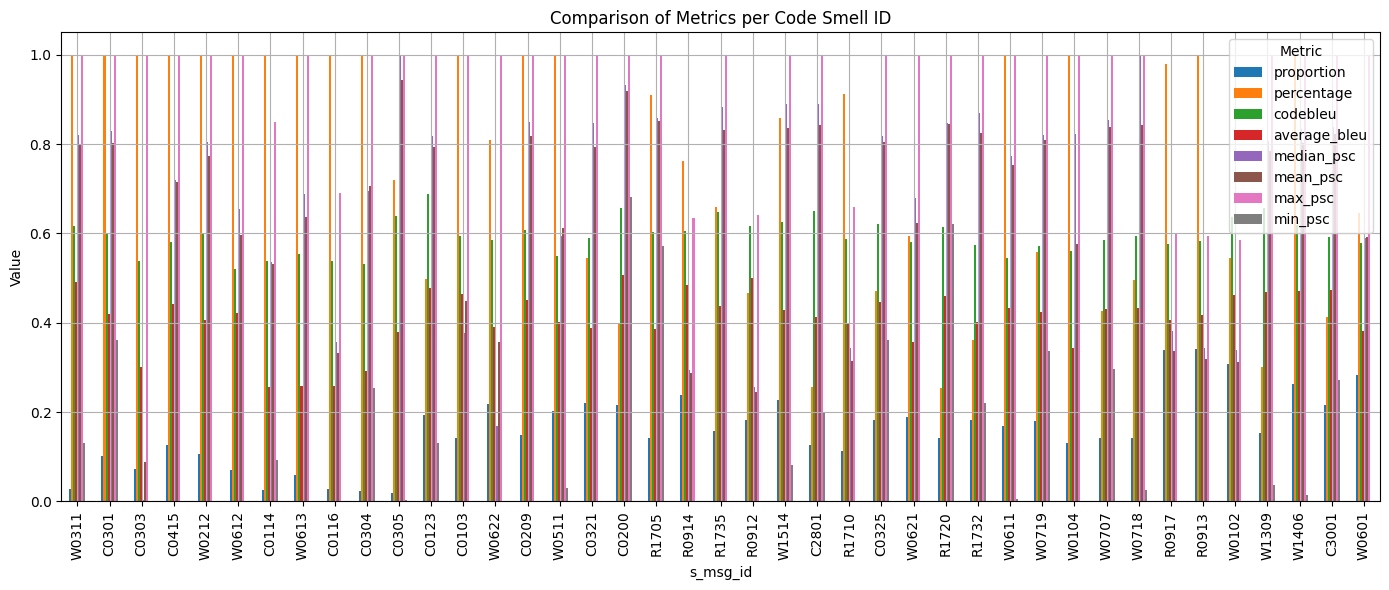

In [20]:
# Create grouped bar plot
ax = metric_results_df.plot(kind='bar', figsize=(14, 6))
plt.title('Comparison of Metrics per Code Smell ID')
plt.ylabel('Value')
plt.xlabel('s_msg_id')
plt.xticks(ticks=range(len(metric_results_df)), labels=metric_results_df['s_msg_id'], rotation=90)
plt.legend(title='Metric')
plt.tight_layout()
plt.grid(True)
plt.show()

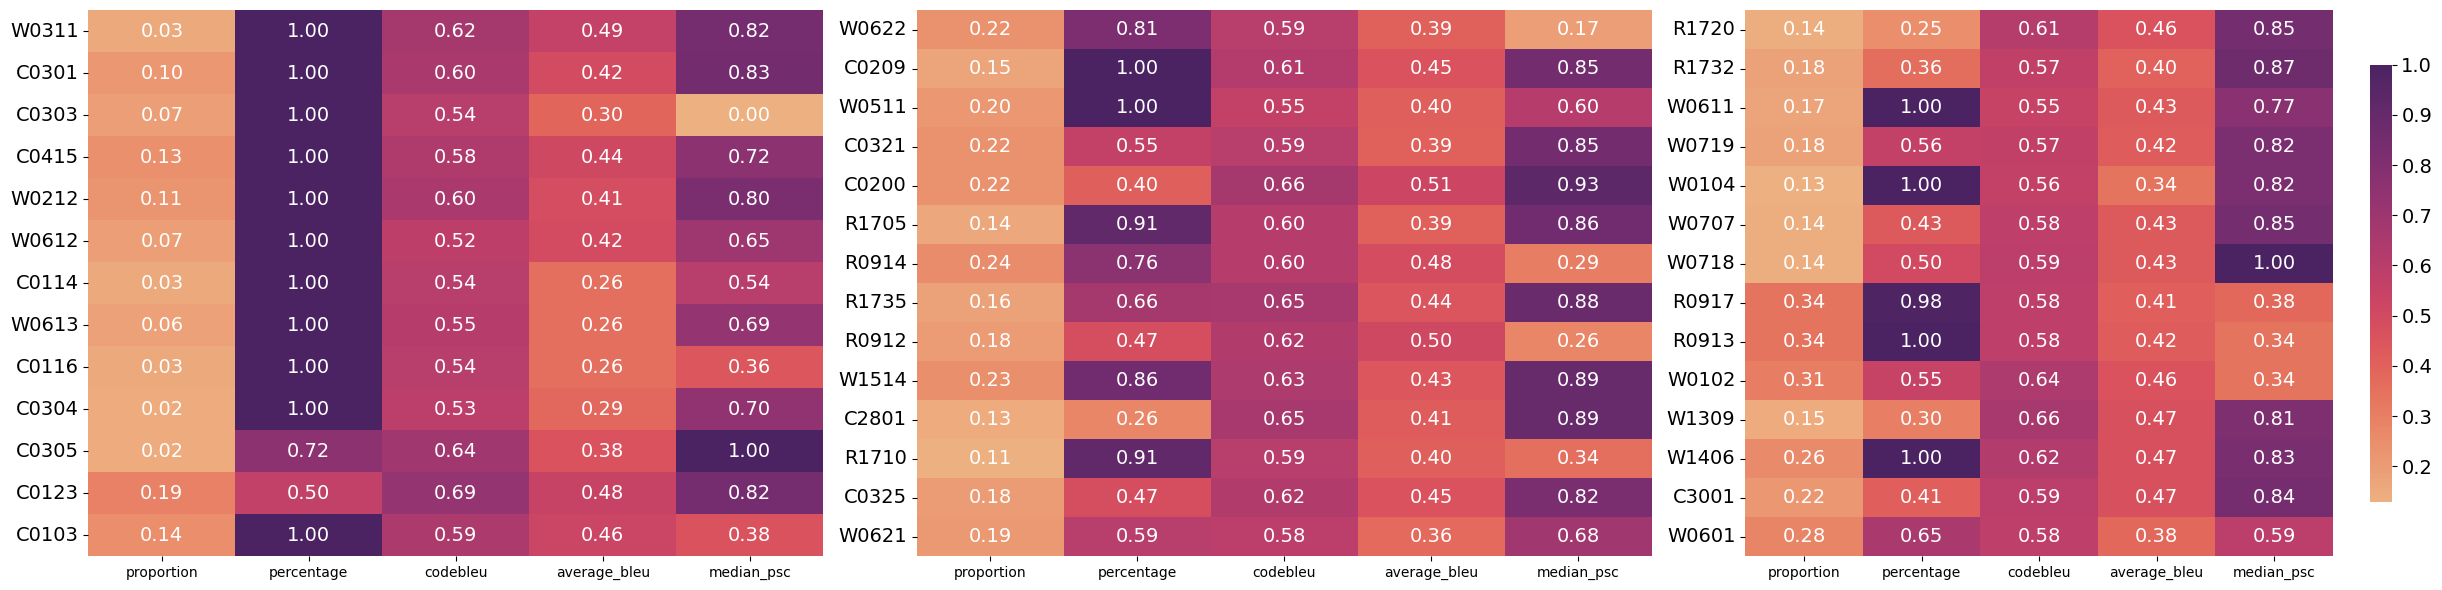

In [21]:
# Select relevant metrics and set index
metrics = ['proportion', 'percentage', 'codebleu', 'average_bleu', 'median_psc']
df_values = metric_results_df.set_index('s_msg_id')[metrics]

# Split into three equal parts
n = len(df_values)
splits = [df_values.iloc[i * n // 3: (i + 1) * n // 3] for i in range(3)]
titles = ["Code Smell Metrics - Part 1", "Part 2", "Part 3"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

# Plot each heatmap
for i, (df_part, title) in enumerate(zip(splits, titles)):
    show_colorbar = (i == 2)  # Show colorbar only on the last subplot
    heatmap = sns.heatmap(
        df_part.round(2),
        annot=True,
        fmt=".2f",
        cmap="flare",
        annot_kws={"size": 14, "color": "white"},
        cbar=show_colorbar,
        cbar_kws={"shrink": 0.8} if show_colorbar else None,
        ax=axes[i]
    )
    axes[i].tick_params(axis='y', labelsize=14)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)
    axes[i].set_ylabel("")

    # If colorbar is shown, increase its label font size
    if show_colorbar:
        heatmap.collections[0].colorbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()


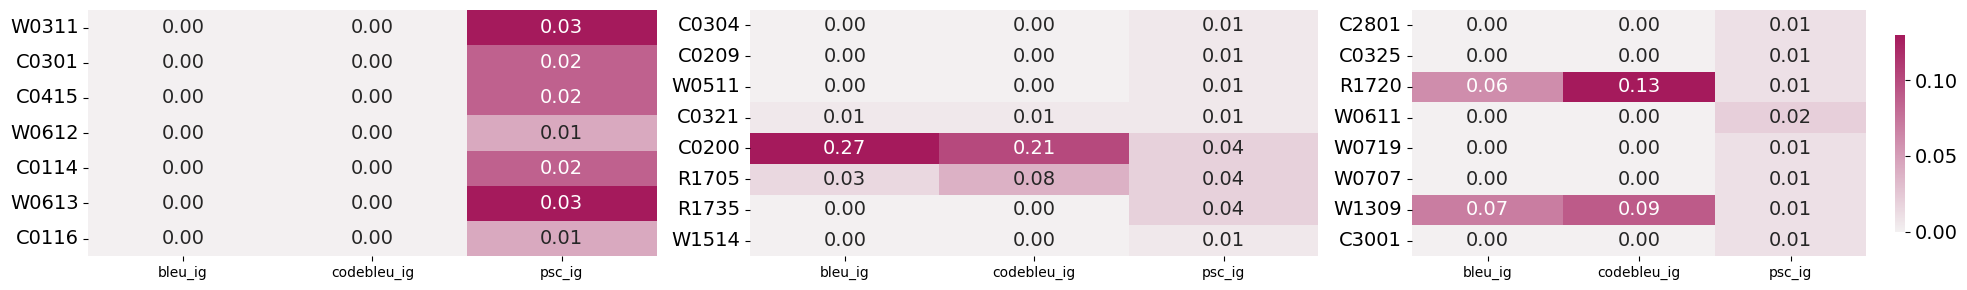

In [24]:
# Select relevant metrics and set index
metrics = ['bleu_ig', 'codebleu_ig', 'psc_ig']
df_values = ig_results_df.set_index('s_msg_id')[metrics]

df_values = df_values[(df_values[metrics] != 0).any(axis=1)]

# Split into three equal parts
n = len(df_values)
splits = [df_values.iloc[i * n // 3: (i + 1) * n // 3] for i in range(3)]
titles = ["Code Smell Metrics - Part 1", "Part 2", "Part 3"]

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(20,3))

# Plot each heatmap
for i, (df_part, title) in enumerate(zip(splits, titles)):
    show_colorbar = (i == 2)  # Show colorbar only on the last subplot
    heatmap = sns.heatmap(
        df_part.round(2),
        annot=True,
        fmt=".2f",
        cmap=sns.light_palette("#A51A5C", as_cmap=True),
        annot_kws={"size": 14},
        cbar=show_colorbar,
        cbar_kws={"shrink": 0.8} if show_colorbar else None,
        ax=axes[i]
    )
    axes[i].tick_params(axis='y', labelsize=14)
    axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)
    axes[i].set_ylabel("")

    # If colorbar is shown, increase its label font size
    if show_colorbar:
        heatmap.collections[0].colorbar.ax.tick_params(labelsize=14)

plt.tight_layout()
plt.show()
